# Homework 4: Model Evaluation and Comparison

BEE 4850/5850, Fall 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/27/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice model evaluation and
using cross-validation and information criteria to distinguish between
models.

-   Problem 1 asks you to fit a model for cherry blossom bloom dates and
    use cross-validation to draw conclusions about generalizability.
-   Problem 2 asks you to compare several linear regression models for
    environmental influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [1]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization package for model fitting
using Dates # API for date-time data structures

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 15 points;

### Problem 1

Let’s examine the influence of global temperature change on the blooming
day of cherry blossoms in Kyoto. While these dates are discrete, we will
use a linear regression model relating the day to the global mean
temperature anomaly for March (the third non-year column in
`data/HadCRUT5.1Analysis_gl.txt`).

#### Problem 1.1

Load the data and fit this model. What does your fitted model suggest as
the influence of March temperature anomalies on the cherry blossom date?

#### Problem 1.2

Calculate the log-loss (negative log-probability) and mean-squared error
metrics for the fitted model on the in-sample data.

#### Problem 1.3

Conduct a 5-fold cross-validation for the model using both of these
metrics. How do they compare to the in-sample metrics?

#### Problem 1.4

What conclusions can you draw about the model’s generalizability?

### Problem 2

Let’s re-examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.


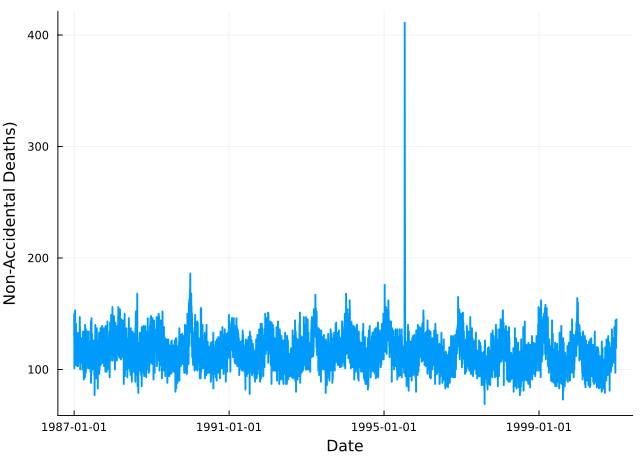

In [1]:
chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)

plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)

#### Problem 2.1

Load and plot the deaths data. Linearly regress the number of deaths
against time and report the coefficients for the fitted model. Add the
regression line to your plot. What does this regression tell you?

#### Problem 2.2

Now linearly regress the deaths data against temperature. Once again,
report the coefficients, and add the regression line to your plot. What
does this regression tell you about the influence of temperature?

#### Problem 2.3

Expand your previous model by regressing deaths against temperature and
PM2.5 density. Report the coefficients and add this regression line to
your plot.

#### Problem 2.4

Conduct a 5-fold cross-validation for the temperature only and
temperature and PM2.5 models, using both the mean-squared-error and
log-probability metrics. Are there any structures in the dataset that
you need to account for when developing your cross-validation folds?
Which model performs the best? What can you conclude from this analysis?

#### Problem 2.5

Compute the AICs for the three fitted models and compare them. What do
they tell you about the relative evidence for the influence of
temperature and PM2.5 density on deaths? How do your conclusions based
on AIC compare to those you might draw from your regression
coefficients, plots, and cross-validation?

## References